tensor([[1.2336, 0.7466],
        [1.0104, 1.0097],
        [0.9615, 0.7374],
        [1.2004, 1.3816],
        [1.0951, 1.2061],
        [0.6825, 0.5725],
        [0.9832, 0.7198],
        [2.1052, 1.6502],
        [1.3745, 0.9683],
        [1.6677, 1.2836]])

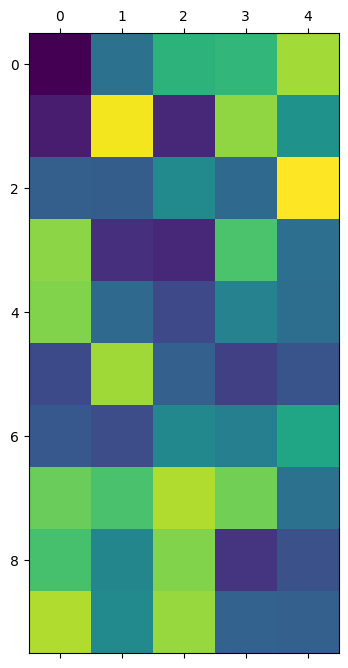

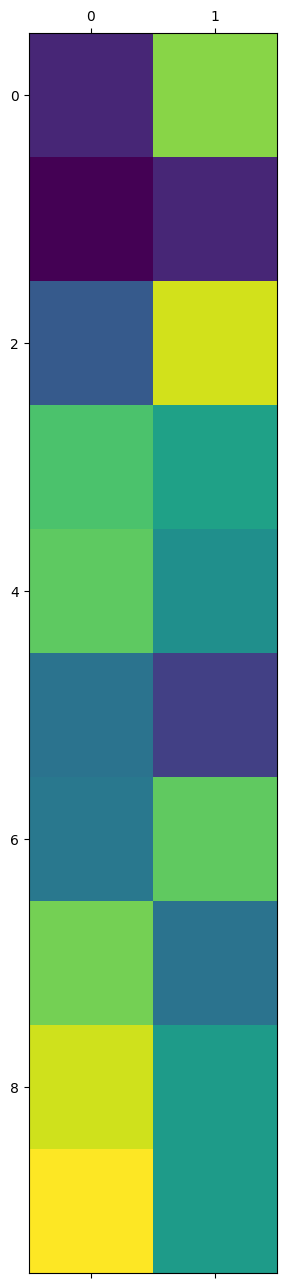

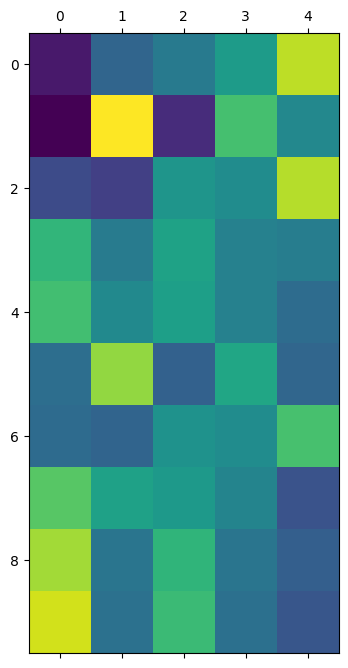

In [2]:
# Goal: Implement PCA on a sample matrix. Find a sweet spot between using an API that does everything for you, 
# and doing things a bit more manually (So maybe implement both, and compare). Use SVD

import torch
from matplotlib import pyplot as plt
from rich import print as pprint


N = 10
n = 5

X = torch.rand(N, n)
Xc = X - X.mean(0, keepdim=True)


U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)

V = Vt.T

k = 2
X_proj = Xc @ V[:, :k]


plt.matshow(Xc)
plt.matshow(X_proj)

X_rec = X_proj @ V[:, :k].T
plt.matshow(X_rec)


# We have 10 data points, they are embedded in a 5D space.
# We want to find the directions which, when the points are projected onto them, the variance of the data is maximized
# Or another way to find the directions are directions which, when the points are projected onto them, the distance the points traveled minimized
# The first direction should be the most variance maximizing one
# These directions are called principal components
# Each principle component is going to be a vector of length 5
# With SVD: X = (somematrix)(some_matrix, with every row being like a direction that the data is stretched to)(some_matrix, which is like the scoring of how effective the principle componnents are)

first_pc = torch.rand(n,2)

projection = X @ first_pc

pprint(projection)



Eigenvalues (variance explained): tensor([0.1933, 0.1090, 0.0980, 0.0628, 0.0109])
Eigen vectors (principle components:) tensor([[-0.7939, -0.0416,  0.2962,  0.2004,  0.4899],
        [ 0.1906, -0.7550, -0.4158,  0.0819,  0.4627],
        [-0.3376,  0.2822, -0.8022,  0.3586, -0.1849],
        [ 0.2139, -0.1490,  0.3051,  0.8904, -0.2148],
        [ 0.4167,  0.5713, -0.0520,  0.1780,  0.6823]])


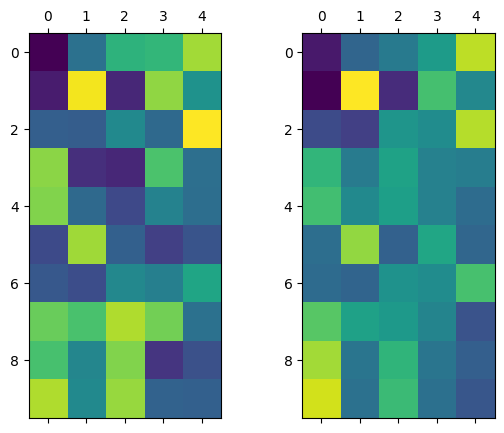

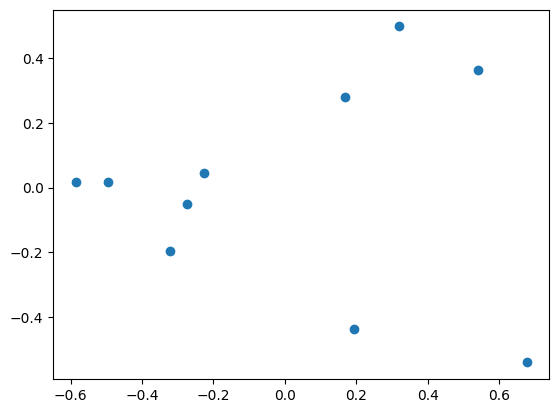

In [ ]:
Cov = (Xc.T @ Xc) / (N - 1)
eigvals, eigvecs = torch.linalg.eigh(Cov)
eigvals, eigvecs = eigvals.flip(0), eigvecs.flip(1)

print("Eigenvalues (variance explained):", eigvals)
print("Eigen vectors (principle components:)", eigvecs)

k = 2
V_k = eigvecs[:, :k]
X_proj = Xc @ V_k

X_recon = X_proj @ V_k.T

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.matshow(Xc, fignum=False)
plt.subplot(1,3,2)
plt.matshow(X_recon, fignum=False)
plt.show()

plt.scatter(X_proj[:, 0], X_proj[:, 1])
plt.show()
plt.scatter(X_proj[:, 0], X_proj[:, 1])
plt.show()